# Build an Autoencoder from scratch (NumPy)

## What we are building

- Input: 2D data
- Latent space: 1D (hard bottleneck)
- Model: Linear autoencoder
- Loss: Mean Squared Error
- Training: Gradient Descent

- Goal: See compression happen

## Setup the experiment
   - **Data rule** : All points lie roughly on a line:  y≈2x
   - This guarantees: 
        - Intrinsic dimension = 1 , there is string correlation between y and x.
        - Bottleneck = 1 makes sense

### Generate the data        

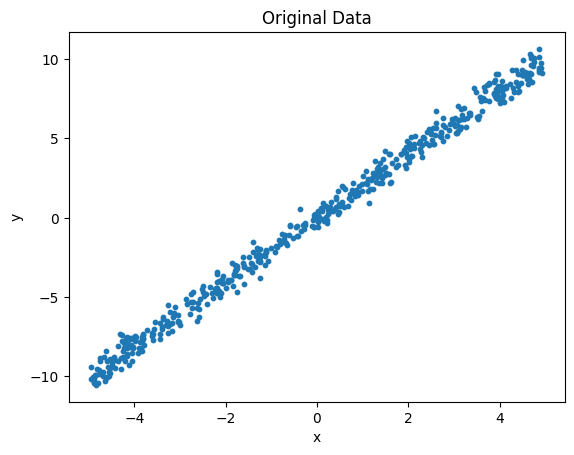

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 2D data lying near a line y = 2x
n_samples = 500
x = np.random.uniform(-5, 5, size=(n_samples, 1))
noise = np.random.normal(0, 0.5, size=(n_samples, 1))
y = 2 * x + noise

X = np.hstack([x, y])  # shape (N, 2)

#print(x)
#print(y)
#print(X)

plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Original Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### Autoencoder architecture

- **Input x**:        (2,)
- **Encoder W_e**:    (1 × 2)
- **Latent z**:       (1,)
- **Decoder W_d**:    (2 × 1)
- **Reconstruction**: (2,)


In [ ]:
# Initialize weights
W_e = np.random.randn(1, 2) * 0.1 # Encoder weights
b_e = np.zeros((1,))

W_d = np.random.randn(2, 1) * 0.1 # Decoder weights
b_d = np.zeros((2,))


### deifne the Network, 

In [6]:
def forward(x):
    """
    x: shape (N, 2)
    """
    z = x @ W_e.T + b_e        # (N, 1)
    x_hat = z @ W_d.T + b_d   # (N, 2)
    return z, x_hat

def mse_loss(x, x_hat):
    return np.mean((x - x_hat) ** 2)

def backward(x, z, x_hat):
    N = x.shape[0]

    # dL/dx_hat
    dx_hat = 2 * (x_hat - x) / N  # (N, 2)

    # Gradients for decoder
    dW_d = dx_hat.T @ z           # (2, 1)
    db_d = dx_hat.sum(axis=0)     # (2,)

    # Backprop to latent
    dz = dx_hat @ W_d             # (N, 1)

    # Gradients for encoder
    dW_e = dz.T @ x               # (1, 2)
    db_e = dz.sum(axis=0)         # (1,)

    return dW_e, db_e, dW_d, db_d



### Training Loop

In [7]:
learning_rate = 0.01
epochs = 2000

for epoch in range(epochs):
    z, x_hat = forward(X)
    loss = mse_loss(X, x_hat)

    dW_e, db_e, dW_d, db_d = backward(X, z, x_hat)

    # Update weights
    W_e -= learning_rate * dW_e
    b_e -= learning_rate * db_e
    W_d -= learning_rate * dW_d
    b_d -= learning_rate * db_d

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 22.6267
Epoch 200, Loss: 0.0249
Epoch 400, Loss: 0.0249
Epoch 600, Loss: 0.0249
Epoch 800, Loss: 0.0249
Epoch 1000, Loss: 0.0249
Epoch 1200, Loss: 0.0249
Epoch 1400, Loss: 0.0249
Epoch 1600, Loss: 0.0248
Epoch 1800, Loss: 0.0248


In [10]:
W_e,W_d

(array([[0.4521311 , 0.89326275]]),
 array([[0.44268052],
        [0.89542569]]))

### Reconstruct the original input by passing to the Network (Encoder -> Decoder)

- forward method takes input X and in forward pass it converts to X_hat. 
- During that process it pass through laten space/bottleneck then it pass to Decoder, which converts it back to same dimension as input.

- We will observer
    - Reconstructed points lie on the learned line
    - Noise is smoothed out
    - Bottleneck captured the dominant direction


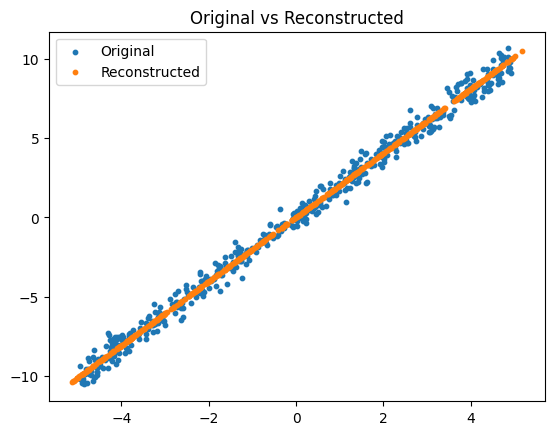

In [8]:
_, X_reconstructed = forward(X)

plt.scatter(X[:, 0], X[:, 1], label="Original", s=10)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], 
            label="Reconstructed", s=10)
plt.legend()
plt.title("Original vs Reconstructed")
plt.show()


### Visualize latent space

- In our network we just have 3 layers, Encoder layer, Latenspace/bottleneck , Decoder layer.
- From our forward method, we are returning output of bottleneck layer and the Decoder layer.
- The output from bottleneck layer is the Latent space.
- Here we are reducing 2D input to 1D Laten space.

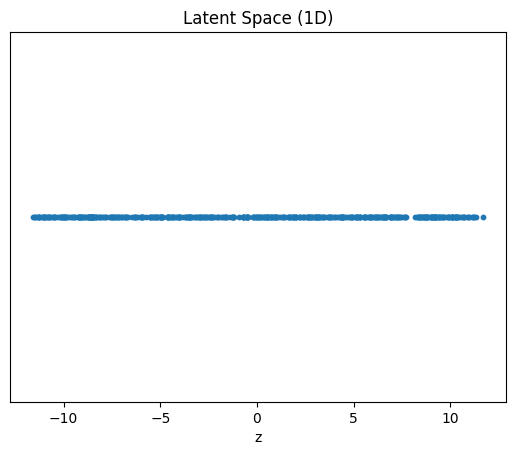

In [9]:
z, _ = forward(X)

plt.scatter(z, np.zeros_like(z), s=10)
plt.title("Latent Space (1D)")
plt.xlabel("z")
plt.yticks([])
plt.show()


## Original vs Reconstructed

### What information was lost
- **Anything that cannot be represented in the bottleneck was lost.**

- Our equaltion was =  **y=2x+ϵ**
    - x = signal
    - 2x = deterministic structure
    - ϵ = noise (random, unpredictable)
- Now we have 2 components
    - Structure
    - Noise

#### What bottleneck can store
 - Our latent space has 1 dimension. So it can encode exactly one scalar per point.
 - Now what is the best Single number to store per point ? 
    - Position **along the line**, not deviation **away from the line**.

#### Geometric interpretation (very important)
 - Each point can be decomposed into: **𝑥 = 𝑥∥ + 𝑥⊥** 
 - Where:
    - **𝑥∥**= component along the line
    - **𝑥⊥**= component orthogonal to the line (noise)
 - The autoencoder:
     - Keeps **𝑥∥** and drops **𝑥⊥**

#### Why is that the optimal thing to lose?
 - Noise is high variance across samples
 - Noise is unpredictable
 - Noise doesn’t help reconstruction on average     

#### Key insight #1
 - **Autoencoders discard information that does not repeat across samples.**
 - Random noise:
    - Does not repeat
    - Is not compressible
    - Is therefore dropped
 
#### Statistical intuition
 - The autoencoder learns:
  -  Given this latent value, what does an average point look like ?
   -  Noise: Averages to zero, cancel itself out.
   - Structure: Reinforces itself	​
#### Why this happens even WITHOUT explicit denoising
 - Bottleneck + MSE = implicit denoiser 
 - **What was lost?**: Random, non-repeatable, orthogonal variation.
 - **why**: Because it cannot be compressed and does not reduce expected loss.

- If you trained on:
    - Perfectly noiseless data → nothing lost
    - Random noise only → model fails completely
    - Mixed signal + noise → signal survives
- **Autoencoder is a signal extractor.**
- **Autoencoders keep what is predictable and discard what is not.**